<a href="https://colab.research.google.com/github/migueromrto-lab/repository/blob/main/Modelo_Propension_PensionPlan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de propensión a compra — pension_plan

Este notebook entrena y evalúa un modelo de propensión a la contratación de
`pension_plan`, priorizado por ser el producto de mayor margen de la cartera
actual (79% del margen total según el análisis exploratorio). El objetivo es
generar un ranking de clientes elegibles para orientar campañas comerciales
de cross-selling, maximizando conversión con un presupuesto de contacto limitado.

**Enfoque:**
- Target: adquisición nueva (cliente sin el producto el mes anterior, que lo
  contrata este mes)
- Features: variables demográficas y de actividad del mes anterior, para evitar
  usar información no disponible en el momento real de decisión
- Split temporal estricto (train / test / validación), respetando la naturaleza
  secuencial de los datos
- Modelo: árbol de decisión, con tuning de profundidad y comparación frente a
  un modelo ensemble (Random Forest)
- Evaluación: métricas técnicas + impacto de negocio esperado (conversión por
  decil de propensión)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Nota: el panel completo (5.9M filas) no se incluye en este repo por tamaño. Simulación:

df_panel = pd.read_parquet('data/df_panel_propension.parquet', engine='pyarrow')

(5961849, 35)


## 1. Definición del target

Consideramos una venta como "target=1" cuando el cliente no tenía `pension_plan`
el mes anterior y sí lo tiene este mes — es decir, una adquisición nueva, no
la simple tenencia continuada del producto. Este es el evento que un modelo de
propensión debe predecir: a quién ofrecer el producto, no quién ya lo tiene.

In [ ]:
df_panel['target'] = df_panel.groupby('pk_cid')['pension_plan'].diff()
df_panel['target'] = df_panel['target'].apply(lambda x: 1 if x == 1 else 0)

print(df_panel['target'].value_counts())
print(f"Total de adquisiciones nuevas de pension_plan: {df_panel['target'].sum()}")

target
0    5924994
1      36855
Name: count, dtype: int64
Total de adquisiciones nuevas de pension_plan: 36855


## 2. Selección de variables y universo elegible

Usamos variables demográficas y de comportamiento, todas referidas al mes
anterior (`_lag1`), para que el modelo solo use información disponible en el
momento real en que se tomaría la decisión de contacto.

Restringimos el universo a clientes que el mes anterior no tenían `pension_plan`
— son los únicos candidatos reales para una campaña de este producto.

In [ ]:
features_base = ['age', 'salary', 'gender', 'segment', 'entry_channel',
                  'active_customer', 'num_products']
lag_cols_necesarias = [f'{c}_lag1' for c in features_base] + ['pension_plan_lag1']

df_model = df_panel.dropna(subset=lag_cols_necesarias).copy()
df_model = df_model[df_model['pension_plan_lag1'] == 0].copy()

print('Filas en el panel completo:', df_panel.shape[0])
print('Filas tras quitar primer mes y filtrar elegibles:', df_model.shape[0])
print(df_model['target'].value_counts())

Filas en el panel completo: 5961849
Filas tras quitar primer mes y filtrar elegibles: 5305179
target
0    5268324
1      36855
Name: count, dtype: int64


In [ ]:
df_model.head()

,pk_cid,pk_partition,short_term_deposit,loans,mortgage,funds,securities,long_term_deposit,em_account_pp,credit_card,...,age_lag1,salary_lag1,gender_lag1,segment_lag1,entry_channel_lag1,active_customer_lag1,num_products_lag1,pension_plan_lag1,em_acount_lag1,target
1,15891,2018-08-01,0,0,0,0,0,0,0,0,...,59.0,88438.2,H,02 - PARTICULARES,KAT,1.0,1.0,0.0,1.0,0
3,16063,2018-12-01,0,0,0,0,0,0,0,0,...,62.0,88438.2,H,02 - PARTICULARES,KAT,1.0,0.0,0.0,0.0,0
4,16063,2019-01-01,0,0,0,0,0,0,0,0,...,62.0,88438.2,H,02 - PARTICULARES,KAT,1.0,0.0,0.0,0.0,0
5,16063,2019-02-01,0,0,0,0,0,0,0,0,...,62.0,88438.2,H,02 - PARTICULARES,KAT,1.0,0.0,0.0,0.0,0
6,16063,2019-03-01,0,0,0,0,0,0,0,0,...,62.0,88438.2,H,02 - PARTICULARES,KAT,1.0,0.0,0.0,0.0,0


## 3. Partición temporal de los datos

El corte es por fecha, no aleatorio: al tratarse de datos mensuales por cliente,
un split aleatorio filtraría información del futuro al pasado. Reservamos el
último mes disponible como validación final y el penúltimo como test,
entrenando con el resto del histórico.

In [ ]:
meses = sorted(df_model['pk_partition'].unique())
mes_val = meses[-1]
mes_test = meses[-2]
print('Mes de test:', mes_test, '| Mes de validacion:', mes_val)

train = df_model[df_model['pk_partition'] < mes_test]
test = df_model[df_model['pk_partition'] == mes_test]
val = df_model[df_model['pk_partition'] == mes_val]

print('Train:', train.shape)
print('Test: ', test.shape)
print('Val:  ', val.shape)

Mes de test: 2019-04-01 00:00:00 | Mes de validacion: 2019-05-01 00:00:00
Train: (4464025, 36)
Test:  (418993, 36)
Val:   (422161, 36)


## 4. Preparación de variables categóricas

`entry_channel` incluye numerosas categorías con muy poca representación, que
solo añaden ruido a un modelo interpretable. Las agrupamos en "Otros",
calculando las frecuencias exclusivamente sobre el conjunto de entrenamiento
para no filtrar información de test/validación. El resto de variables
categóricas se codifican con One-Hot Encoding.

In [ ]:
frecuencias = train['entry_channel_lag1'].value_counts(normalize=True)
categorias_frecuentes = frecuencias[frecuencias >= 0.01].index

def agrupar_entry_channel(serie):
    return serie.where(serie.isin(categorias_frecuentes), 'Otros')

train = train.copy()
test = test.copy()
val = val.copy()
train['entry_channel_lag1'] = agrupar_entry_channel(train['entry_channel_lag1'])
test['entry_channel_lag1']  = agrupar_entry_channel(test['entry_channel_lag1'])
val['entry_channel_lag1']   = agrupar_entry_channel(val['entry_channel_lag1'])

print('Categorias de entry_channel tras agrupar:', train['entry_channel_lag1'].nunique())

cat_cols = ['gender_lag1', 'segment_lag1', 'entry_channel_lag1']
num_cols = ['age_lag1', 'salary_lag1', 'active_customer_lag1', 'num_products_lag1']

X_train = pd.get_dummies(train[num_cols + cat_cols], columns=cat_cols)
X_test  = pd.get_dummies(test[num_cols + cat_cols], columns=cat_cols)
X_val   = pd.get_dummies(val[num_cols + cat_cols], columns=cat_cols)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)

y_train = train['target']
y_test = test['target']
y_val = val['target']

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('X_val:  ', X_val.shape)

Categorias de entry_channel tras agrupar: 11
X_train: (4464025, 21)
X_test:  (418993, 21)
X_val:   (422161, 21)


## 5. Selección de la profundidad del modelo

Evaluamos distintas profundidades del árbol, midiendo el AUC en el conjunto de
test, para encontrar el punto de equilibrio entre capacidad predictiva y
sobreajuste. No usamos validación cruzada estándar, ya que reintroduciría
mezcla temporal entre periodos — mantenemos el mismo criterio de partición
por fecha que en el resto del proceso.



   max_depth  n_hojas  auc_train  auc_test  gap_overfitting
0        3.0        8   0.850764  0.843795         0.006970
1        4.0       16   0.859345  0.852075         0.007270
2        5.0       32   0.868678  0.862328         0.006350
3        6.0       62   0.875533  0.870142         0.005391
4        7.0      120   0.878595  0.872000         0.006596
5        8.0      220   0.881286  0.872035         0.009251
6       10.0      628   0.887326  0.870558         0.016768
7       12.0     1499   0.894373  0.863824         0.030549
8        NaN    53834   0.992870  0.681220         0.311650


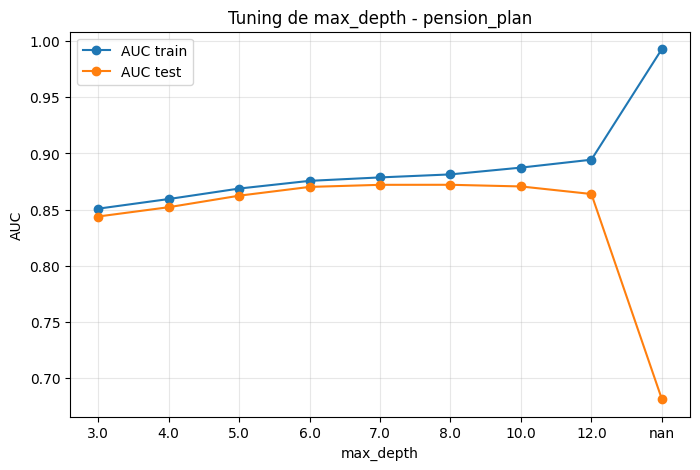

Mejor max_depth según AUC test: 8.0


In [ ]:
"""## 5. Tuning: búsqueda de max_depth óptimo

GridSearchCV no es apropiado aquí porque su validación cruzada por defecto es
aleatoria, lo que reintroduciría el leakage temporal que evitamos a mano con el
split train/test/val. En su lugar, hacemos una búsqueda manual: entrenamos con
train y evaluamos AUC en test (nunca en val, que se reserva para el final).
"""

from sklearn.metrics import roc_auc_score

profundidades = [3, 4, 5, 6, 7, 8, 10, 12, None]
resultados_tuning = []

for depth in profundidades:
    modelo_tmp = DecisionTreeClassifier(
        max_depth=depth, class_weight='balanced', random_state=42
    )
    modelo_tmp.fit(X_train, y_train)

    proba_train = modelo_tmp.predict_proba(X_train)[:, 1]
    proba_test = modelo_tmp.predict_proba(X_test)[:, 1]

    auc_train = roc_auc_score(y_train, proba_train)
    auc_test = roc_auc_score(y_test, proba_test)

    resultados_tuning.append({
        'max_depth': depth,
        'n_hojas': modelo_tmp.get_n_leaves(),
        'auc_train': auc_train,
        'auc_test': auc_test,
        'gap_overfitting': auc_train - auc_test
    })

df_tuning = pd.DataFrame(resultados_tuning)
print(df_tuning)

# Visualización: AUC train vs test por profundidad, para detectar overfitting a simple vista
plt.figure(figsize=(8, 5))
plt.plot(df_tuning['max_depth'].astype(str), df_tuning['auc_train'], marker='o', label='AUC train')
plt.plot(df_tuning['max_depth'].astype(str), df_tuning['auc_test'], marker='o', label='AUC test')
plt.xlabel('max_depth')
plt.ylabel('AUC')
plt.title('Tuning de max_depth - pension_plan')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

"""Elegimos el max_depth con mejor AUC en test, priorizando evitar overfitting
(gap grande entre AUC train y test) si hay varias opciones similares."""

mejor_depth = df_tuning.loc[df_tuning['auc_test'].idxmax(), 'max_depth']
print(f'Mejor max_depth según AUC test: {mejor_depth}')

Aunque el mejor AUC lo obtenemos con la max_depth de 8, con 7 practicamente tenemos el mismo AUC, pero con bastante menos gap_overfitting (0.66 por 0.93). Por eso, elegimos el 7

## 5. Modelo

Arbol de decision poco profundo (`max_depth=5`, interpretable) con `class_weight='balanced'`: el propio modelo compensa que solo un ~0.7% del train sea target=1, dandole mas peso a esos casos en vez de tirar datos (como haria un undersampling).

In [ ]:
modelo = DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42)
modelo.fit(X_train, y_train)
print('Modelo entrenado correctamente.')

Modelo entrenado correctamente.


## Variables más relevantes

Analizamos qué variables pesan más en las decisiones del modelo, como insumo
para las áreas de negocio: entender qué perfil de cliente es más propenso a
contratar el producto es tan valioso como el propio ranking de contacto.

active_customer_lag1               0.727291
age_lag1                           0.122125
num_products_lag1                  0.056765
segment_lag1_03 - UNIVERSITARIO    0.021285
entry_channel_lag1_KHE             0.014839
salary_lag1                        0.013027
segment_lag1_01 - TOP              0.010309
segment_lag1_Desconocido           0.009199
entry_channel_lag1_KHQ             0.006580
segment_lag1_02 - PARTICULARES     0.004776
entry_channel_lag1_KHM             0.004637
entry_channel_lag1_KHN             0.004092
entry_channel_lag1_KHK             0.001804
entry_channel_lag1_KFC             0.001643
entry_channel_lag1_KHD             0.001352
dtype: float64


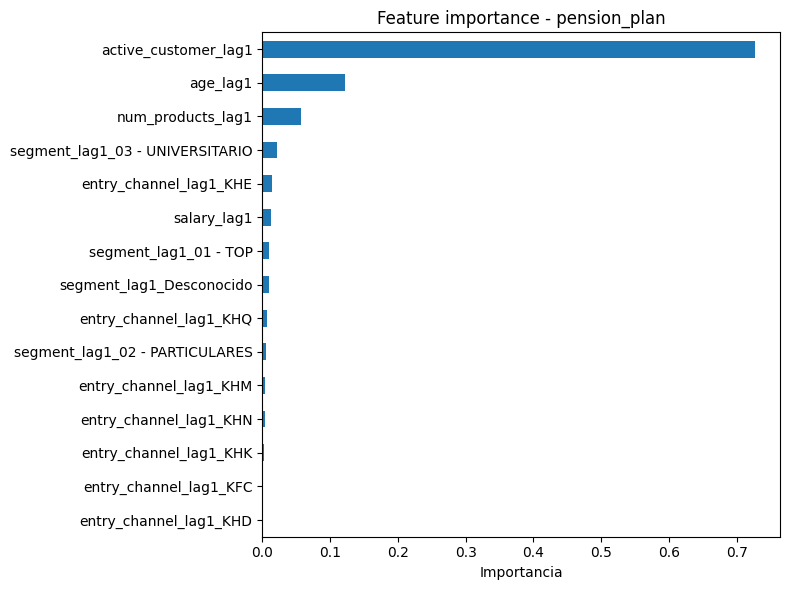

In [ ]:
importancias = pd.Series(
    modelo.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

print(importancias.head(15))

plt.figure(figsize=(8, 6))
importancias.head(15).sort_values().plot(kind='barh')
plt.xlabel('Importancia')
plt.title('Feature importance - pension_plan')
plt.tight_layout()
plt.show()

In [ ]:
importancias_agrupadas = importancias.groupby(
    importancias.index.str.replace(r'_lag1.*', '', regex=True)
).sum().sort_values(ascending=False)
print(importancias_agrupadas)

active_customer    0.727291
age                0.122125
num_products       0.056765
segment            0.045569
entry_channel      0.035108
salary             0.013027
gender             0.000115
dtype: float64


**Idea para memoria**:
"Antes de lanzar una campaña de pension_plan, puede ser más rentable invertir en activar clientes dormidos en la app que en segmentar por edad o canal de entrada — porque el modelo indica que la actividad es el driver principal."

## 6. Validación del modelo

Evaluamos el modelo sobre el mes de test con métricas estándar de
clasificación. La curva ROC se calcula con la probabilidad predicha
(`predict_proba`), no con la clase asignada por defecto, para poder analizar
el comportamiento del modelo a distintos umbrales de decisión.

              precision    recall  f1-score   support

   No compra       1.00      0.75      0.86    416719
      Compra       0.02      0.87      0.04      2274

    accuracy                           0.75    418993
   macro avg       0.51      0.81      0.45    418993
weighted avg       0.99      0.75      0.85    418993



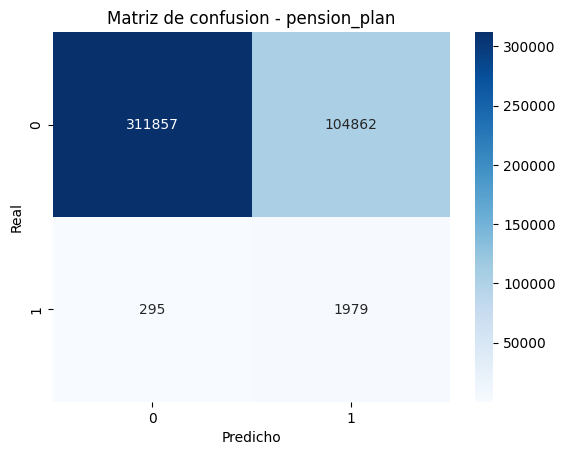

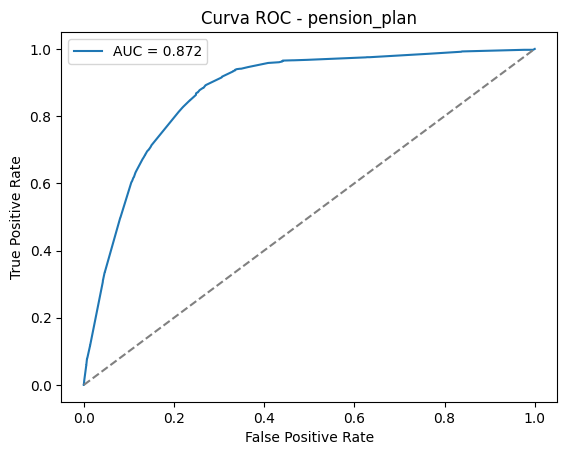

In [ ]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No compra', 'Compra']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusion - pension_plan')
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - pension_plan')
plt.legend()
plt.show()

## Comparación con un modelo ensemble

Contrastamos el árbol de decisión con un Random Forest entrenado bajo las
mismas condiciones, para valorar si la ganancia de un modelo más complejo
compensa la pérdida de interpretabilidad directa frente al equipo de negocio

AUC Decision Tree (test): 0.8720
AUC Random Forest (test): 0.8744
Diferencia: +0.0024

Valores únicos de probabilidad - Decision Tree: 96
Valores únicos de probabilidad - Random Forest: 71682


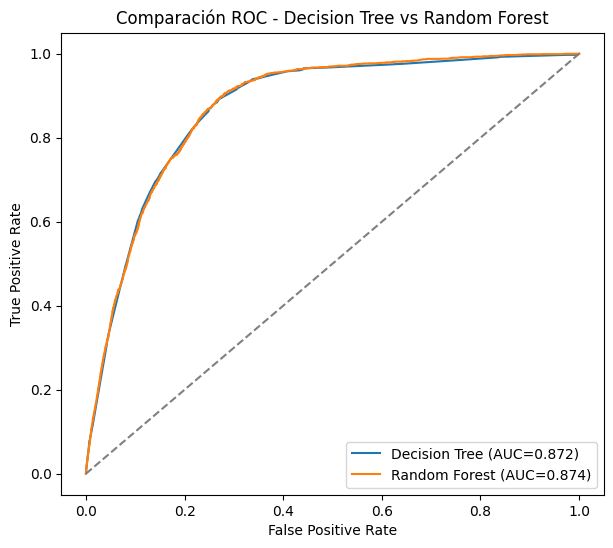

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    max_depth=8,       # misma profundidad que el árbol ganador, para comparar en igualdad de condiciones
    n_estimators=200,             # nº de árboles del ensemble
    class_weight='balanced',      # mismo tratamiento del desbalanceo que el árbol
    random_state=42,
    n_jobs=-1                     # paraleliza en todos los cores disponibles
)
modelo_rf.fit(X_train, y_train)

# --- Comparación de AUC en test ---
proba_test_arbol = modelo.predict_proba(X_test)[:, 1]
proba_test_rf = modelo_rf.predict_proba(X_test)[:, 1]

auc_arbol = roc_auc_score(y_test, proba_test_arbol)
auc_rf = roc_auc_score(y_test, proba_test_rf)

print(f'AUC Decision Tree (test): {auc_arbol:.4f}')
print(f'AUC Random Forest (test): {auc_rf:.4f}')
print(f'Diferencia: {auc_rf - auc_arbol:+.4f}')

# --- Comparación de granularidad de probabilidad (recordar el problema inicial) ---
print(f'\nValores únicos de probabilidad - Decision Tree: {pd.Series(proba_test_arbol).nunique()}')
print(f'Valores únicos de probabilidad - Random Forest: {pd.Series(proba_test_rf).nunique()}')

# --- Curvas ROC superpuestas, para comparar visualmente ---
fpr_arbol, tpr_arbol, _ = roc_curve(y_test, proba_test_arbol)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_test_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_arbol, tpr_arbol, label=f'Decision Tree (AUC={auc_arbol:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparación ROC - Decision Tree vs Random Forest')
plt.legend()
plt.show()

El Random Forest apenas mejora el AUC respecto al árbol simple (+0.0024), confirmando que la señal predictiva está mayormente capturada por una variable dominante (active_customer) que ya un árbol poco profundo explota bien. Sin embargo, el ensemble multiplica por ~750 la granularidad de las probabilidades predichas (de 96 a 71.682 valores únicos), lo que lo hace preferible si el objetivo es un ranking fino de clientes (por ejemplo, para decidir a quién contactar primero dentro del propio decil 1). Para explicar el modelo a negocio, mantenemos el árbol de decisión como modelo de referencia por su interpretabilidad directa; para producción, recomendaríamos el Random Forest.

## 7. Impacto esperado en campaña

En una campaña real, no se contacta a toda la base de clientes: se prioriza a
quienes el modelo identifica como más propensos. Evaluamos, sobre el mes de
validación (nunca usado en el entrenamiento ni en la selección del modelo),
qué conversión se conseguiría contactando distintos porcentajes de la base,
ordenados por probabilidad predicha.

Clientes evaluados en validacion: 422161
Clientes en el top 5%: 21108
Compras reales dentro del top: 981
Tasa de conversion en el top 5%: 4.65%
Tasa de conversion si contactases al azar: 0.66%
El modelo mejora la conversion x7.0 frente a contactar al azar
       n_clientes  compras_reales  tasa_conversion      lift  \
decil                                                          
1           42217            1535         0.036360  5.499704   
2           42216             632         0.014971  2.264427   
3           42216             358         0.008480  1.282697   
4           42216             135         0.003198  0.483699   
5           42216              48         0.001137  0.171982   
6           42216              14         0.000332  0.050161   
7           42216              14         0.000332  0.050161   
8           42216              22         0.000521  0.078825   
9           42216              11         0.000261  0.039412   
10          42216              22       

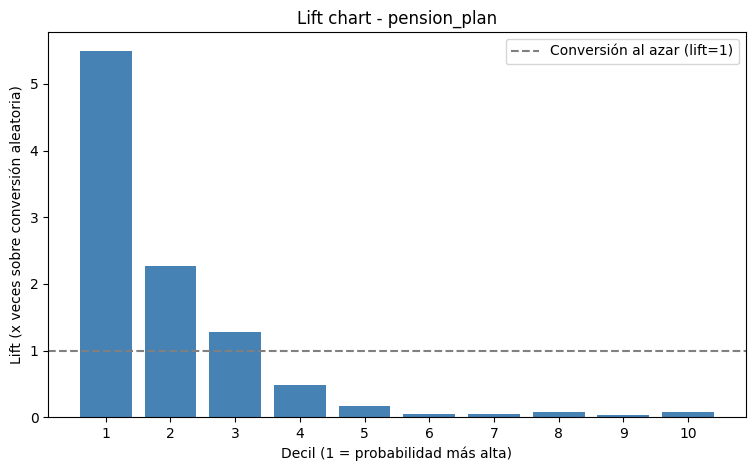

In [ ]:
# ============================================================
# Evaluación de negocio: conversión real por decil de probabilidad
# (mes de validación, el único que no hemos tocado para nada más)
# ============================================================

# Probabilidad predicha por el modelo para cada cliente del mes de validación
val_proba = modelo.predict_proba(X_val)[:, 1]

# Tabla con cliente, probabilidad predicha y si realmente compró (target real)
df_sim = pd.DataFrame({
    'pk_cid': val['pk_cid'].values,
    'probabilidad': val_proba,
    'compra_real': y_val.values
}).sort_values(by='probabilidad', ascending=False)

# Tasa de conversion de referencia: la que obtendríamos si contactásemos
# clientes al azar, sin usar ningún modelo
tasa_base = df_sim['compra_real'].mean()

# --- Caso simple: top 5% de clientes por probabilidad ---
top_pct = 0.05
top_n = int(len(df_sim) * top_pct)
top_clientes = df_sim.head(top_n)

compras_en_top = top_clientes['compra_real'].sum()
tasa_conversion_top = compras_en_top / top_n

print(f'Clientes evaluados en validacion: {len(df_sim)}')
print(f'Clientes en el top {top_pct*100:.0f}%: {top_n}')
print(f'Compras reales dentro del top: {compras_en_top}')
print(f'Tasa de conversion en el top {top_pct*100:.0f}%: {tasa_conversion_top*100:.2f}%')
print(f'Tasa de conversion si contactases al azar: {tasa_base*100:.2f}%')
print(f'El modelo mejora la conversion x{tasa_conversion_top/tasa_base:.1f} frente a contactar al azar')

# --- Vista completa: decile/lift chart ---
# Partimos a TODOS los clientes en 10 grupos iguales segun su probabilidad
# predicha (decil 1 = probabilidad mas alta, decil 10 = mas baja). Usamos
# rank(method='first') antes del qcut porque muchas filas comparten la MISMA
# probabilidad exacta (el arbol asigna la misma probabilidad a todos los
# clientes de una misma hoja) -- sin el rank, qcut no podria partir los datos
# en 10 grupos de tamano igual si hay demasiados valores repetidos.
df_sim['decil'] = pd.qcut(
    df_sim['probabilidad'].rank(method='first', ascending=False),
    10, labels=False
) + 1  # +1 para que los deciles vayan de 1 a 10 en vez de 0 a 9

# Para cada decil: cuantos clientes hay, cuantas compras reales hubo, y la
# tasa de conversion real dentro de ese decil
lift_table = df_sim.groupby('decil').agg(
    n_clientes=('pk_cid', 'count'),
    compras_reales=('compra_real', 'sum'),
    tasa_conversion=('compra_real', 'mean')
)

# Lift = cuantas veces mejor convierte este decil frente a contactar al azar
lift_table['lift'] = lift_table['tasa_conversion'] / tasa_base

# % acumulado de TODAS las compras reales que capturariamos si contactasemos
# desde el decil 1 hasta este decil incluido (util para decidir cuantos
# deciles contactar en una campana real, no solo mirar el top 5% aislado)
lift_table['pct_compras_capturadas'] = (
    lift_table['compras_reales'].cumsum() / lift_table['compras_reales'].sum() * 100
)

print(lift_table)

# Grafico de barras: lift por decil, con linea de referencia en 1
# (=contactar al azar, sin ningun modelo). El decil 1 deberia tener el lift
# mas alto, bajando de forma mas o menos monotona hacia el decil 10
plt.figure(figsize=(9, 5))
plt.bar(lift_table.index, lift_table['lift'], color='steelblue')
plt.axhline(1, color='gray', linestyle='--', label='Conversión al azar (lift=1)')
plt.xlabel('Decil (1 = probabilidad más alta)')
plt.ylabel('Lift (x veces sobre conversión aleatoria)')
plt.title('Lift chart - pension_plan')
plt.xticks(lift_table.index)
plt.legend()
plt.show()

## Resultados y recomendación

El modelo permite multiplicar por 5-7 veces la conversión de una campaña de
`pension_plan` frente a un contacto no dirigido, concentrando la mayor parte
del valor en el 10-30% superior de la base ordenada por probabilidad.
Recomendamos priorizar el contacto comercial en ese segmento, donde el coste
de campaña se traduce en la conversión más alta por cliente contactado.

## 8. Aplicación sobre la cartera actual

Con el modelo ya validado, generamos el ranking de propensión sobre el estado
más reciente de la cartera, listo para su uso en la próxima campaña comercial.

In [ ]:
# Último mes disponible: tratamos sus valores como el "mes anterior" al que
# todavía no existe en los datos (el mes que viene)
ultimo_mes = df_model['pk_partition'].max()
df_actual = df_panel[df_panel['pk_partition'] == ultimo_mes].copy()

# Solo clientes que HOY no tienen pension_plan
df_actual = df_actual[df_actual['pension_plan'] == 0].copy()

# Agrupamos entry_channel con las mismas categorías frecuentes que usamos en el modelo
df_actual['entry_channel'] = df_actual['entry_channel'].where(
    df_actual['entry_channel'].isin(categorias_frecuentes), 'Otros'
)

# Mismas columnas que vio el modelo en el entrenamiento (renombradas a "_lag1"
# porque, desde el punto de vista del modelo, representan "el mes anterior")
X_actual = pd.get_dummies(
    df_actual[['age', 'salary', 'active_customer', 'num_products', 'gender', 'segment', 'entry_channel']]
    .rename(columns={
        'age': 'age_lag1', 'salary': 'salary_lag1',
        'active_customer': 'active_customer_lag1', 'num_products': 'num_products_lag1',
        'gender': 'gender_lag1', 'segment': 'segment_lag1', 'entry_channel': 'entry_channel_lag1'
    }),
    columns=['gender_lag1', 'segment_lag1', 'entry_channel_lag1']
)
X_actual = X_actual.reindex(columns=X_train.columns, fill_value=0)

proba_actual = modelo.predict_proba(X_actual)[:, 1]

df_scoring = pd.DataFrame({
    'pk_cid': df_actual['pk_cid'].values,
    'probabilidad_pension_plan': proba_actual
}).sort_values(by='probabilidad_pension_plan', ascending=False).reset_index(drop=True)

print(f'Clientes elegibles para pension_plan hoy: {len(df_scoring)}')
print(df_scoring.head(20))

df_scoring.to_csv('data/scoring_pension_plan.csv', index=False)
print('Guardado en data/scoring_pension_plan.csv')

Clientes elegibles para pension_plan hoy: 425556
     pk_cid  probabilidad_pension_plan
0   1097934                   0.906471
1   1005321                   0.906471
2   1123666                   0.906471
3   1477448                   0.906471
4   1374196                   0.906471
5   1005302                   0.906471
6   1123673                   0.906471
7   1021617                   0.906471
8   1005290                   0.906471
9   1384007                   0.906471
10  1189322                   0.906471
11  1005259                   0.906471
12  1005252                   0.906471
13  1243395                   0.906471
14  1083865                   0.906471
15  1243390                   0.906471
16  1116120                   0.906471
17  1058817                   0.906471
18  1172124                   0.906471
19  1420480                   0.906471
Guardado en data/scoring_pension_plan.csv
